# Лабораторная работа №1 (МОиРО)
## Моделирование экспериментальных данных для задач распознавания образов
### Вариант 13 ###
### Выполнил: студент группы 6413 Шаменков М.А. ###


## Исходные данные
$$M_1=(-1,1)^T,\quad M_2=(0,-1)^T,\quad M_3=(2,-1)^T.$$ 

Шаблоны букв «Я» и «Ю» заданы матрицами 9×9 (0/1).

## 1. Теоретическая база
### 1.1 Нормальный случайный вектор
Пусть $X=(X_1,X_2)^T$ — двумерный случайный вектор, имеющий нормальный закон распределения:
$$X\sim\mathcal{N}(M,B).$$
Параметры распределения:
- $M$ — вектор математических ожиданий (центр облака точек);
- $B$ — ковариационная матрица (форма/ориентация эллипса рассеяния).

По методичке, $X$ можно получить линейным преобразованием стандартного нормального вектора $\xi$:
$$\boxed{X=A\,\xi+M},\qquad \xi\sim\mathcal{N}(0,I).$$
Матрица $A$ выбирается так, чтобы:
$$\boxed{B=AA^T}.$$

Для случая $n=2$:
$$a_{00}=\sqrt{B_{00}},\qquad a_{10}=\frac{B_{01}}{a_{00}},\qquad a_{11}=\sqrt{B_{11}-a_{10}^2}.$$

### 1.2 Оценивание параметров (оценки максимального правдоподобия)
По выборке $\{x_i\}_{i=1}^N$:
$$\boxed{\hat M=\frac{1}{N}\sum_{i=1}^{N}x_i}$$
$$\boxed{\hat B=\frac{1}{N}\sum_{i=1}^{N}(x_i-\hat M)(x_i-\hat M)^T}$$

### 1.3 Меры близости распределений
Для двух нормальных распределений $\mathcal{N}(M_0,B_0)$ и $\mathcal{N}(M_1,B_1)$:

**Расстояние Бхатачария**:
$$\boxed{\rho_B = \frac18\Delta M^T\left(\frac{B_0+B_1}{2}\right)^{-1}\Delta M
+\frac12\ln\frac{\det\left(\frac{B_0+B_1}{2}\right)}{\sqrt{\det(B_0)\det(B_1)}}}$$

Если $B_0=B_1=B$, то часто используют **расстояние Махаланобиса**:
$$\boxed{\rho_M=\Delta M^T B^{-1}\Delta M},\qquad \Delta M=M_1-M_0.$$

#### Исходные данные лабораторной работы

In [1]:
import numpy as np
import matplotlib.pyplot as plt

seed = 42
rng = np.random.default_rng(seed)

N = 200

p_flip = 0.05

M1 = np.array([-1.0,  1.0])
M2 = np.array([ 0.0, -1.0])
M3 = np.array([ 2.0, -1.0])


#### Генерация стандартного нормального распределения

Проверка ξ: mean = -0.00045788468152627046 var = 0.9955373593294286


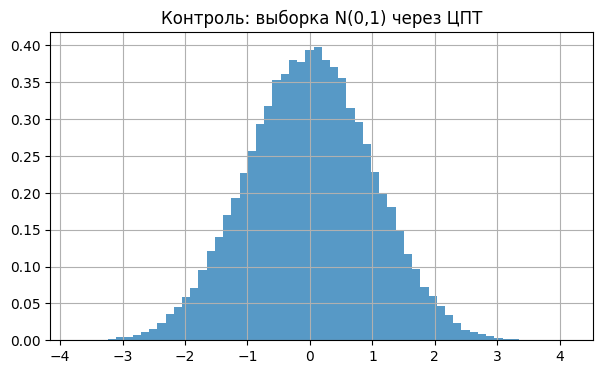

In [2]:
def std_normal_clt(size, rng, m=12):
    U = rng.uniform(0.0, 1.0, size=(m,) + tuple(size))
    S = U.sum(axis=0)
    Z = (S - m/2.0) / np.sqrt(m/12.0)
    return Z


def std_normal(size, rng):
    return std_normal_clt(size=size, rng=rng, m=12)


z = std_normal(size=(100000,), rng=rng)
print("Проверка ξ: mean =", z.mean(), "var =", z.var())

plt.figure(figsize=(7,4))
plt.hist(z, bins=60, density=True, alpha=0.75)
plt.grid(True)
plt.title("Контроль: выборка N(0,1) через ЦПТ")
plt.show()


#### Построение матрицы A преобразования

In [3]:
def build_A_from_B_2d(B):
    B00 = B[0, 0]
    B01 = B[0, 1]
    B11 = B[1, 1]

    a00 = np.sqrt(B00)
    a10 = B01 / a00
    under = B11 - a10**2
    if under <= 0:
        raise ValueError("Матрица B должна быть положительно определённой: B11 - a10^2 > 0.")
    a11 = np.sqrt(under)

    A = np.array([[a00, 0.0],
                  [a10, a11]], dtype=float)
    return A


def sample_gaussian_2d(M, B, N, rng):
    A = build_A_from_B_2d(B)
    xi = std_normal(size=(N, 2), rng=rng)
    X = (A @ xi.T).T + M.reshape(1, 2)
    return X


def check_B_equals_AAT(B):
    A = build_A_from_B_2d(B)
    B_check = A @ A.T
    return np.max(np.abs(B - B_check))


#### Матрица B

In [4]:
def covariance_from_sigmas_rho(sigma1, sigma2, rho):
    var1 = sigma1**2
    var2 = sigma2**2
    cov = rho * sigma1 * sigma2
    return np.array([[var1, cov],
                     [cov,  var2]], dtype=float)


In [5]:
def mle_estimates(X):
    N = X.shape[0]
    M_hat = np.sum(X, axis=0) / N
    Xc = X - M_hat.reshape(1, 2)
    B_hat = (Xc.T @ Xc) / N
    return M_hat, B_hat


#### Расстояния: Бхатачария и Махаланобис

In [6]:
def bhattacharyya_distance(M0, B0, M1, B1):
    dM = (np.asarray(M1) - np.asarray(M0)).reshape(2, 1)
    B_avg = (np.asarray(B0) + np.asarray(B1)) / 2.0
    term1 = (1.0/4.0) * (dM.T @ np.linalg.inv(B_avg) @ dM).item()
    term2 = 0.5 * np.log(
        np.linalg.det(B_avg) / np.sqrt(np.linalg.det(B0) * np.linalg.det(B1))
    )

    return term1 + term2


def mahalanobis_distance_equal_B(M0, M1, B):
    dM = (np.asarray(M1) - np.asarray(M0)).reshape(2, 1)
    return (dM.T @ np.linalg.inv(B) @ dM).item()



In [7]:
def plot_2d_samples(X_list, labels, title):
    plt.figure(figsize=(7,6))
    for X, lab in zip(X_list, labels):
        plt.scatter(X[:,0], X[:,1], s=18, alpha=0.75, label=lab)
    plt.grid(True)
    plt.axis("equal")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.show()


## 2. Выполнение работы
### Две выборки (N=200) для двух классов с одинаковой B

B_equal =
 [[0.16  0.032]
 [0.032 0.16 ]]
Проверка B≈AA^T, max|B-AA^T| = 2.7755575615628914e-17

Оценки (Шаг 2):
Class 1: M_hat = [-0.96950108  0.98708045] 
B_hat=
 [[0.18224284 0.02187157]
 [0.02187157 0.16677208]]
Class 2: M_hat = [ 0.02905409 -1.02406828] 
B_hat=
 [[0.17948299 0.05515007]
 [0.05515007 0.17486356]]

Меры близости (истинные параметры):
rho_B (Бхатачария) = 9.440104166666664
rho_M (Махаланобис) = 37.76041666666666


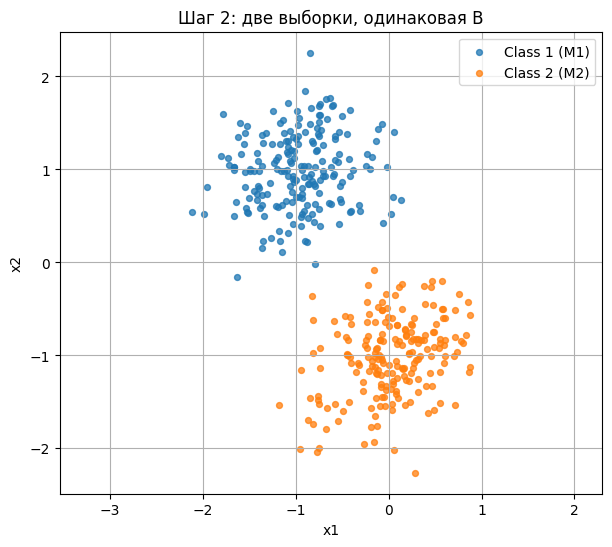

In [8]:
sigma1_eq = 0.40
sigma2_eq = 0.40
rho_eq = 0.2

B_equal = covariance_from_sigmas_rho(sigma1_eq, sigma2_eq, rho_eq)

print("B_equal =\n", B_equal)
print("Проверка B≈AA^T, max|B-AA^T| =", check_B_equals_AAT(B_equal))

X1_eq = sample_gaussian_2d(M1, B_equal, N, rng)
X2_eq = sample_gaussian_2d(M2, B_equal, N, rng)

M1_hat_eq, B1_hat_eq = mle_estimates(X1_eq)
M2_hat_eq, B2_hat_eq = mle_estimates(X2_eq)

rhoB_eq = bhattacharyya_distance(M1, B_equal, M2, B_equal)
rhoM_eq = mahalanobis_distance_equal_B(M1, M2, B_equal)

print("\nОценки (Шаг 2):")
print("Class 1: M_hat =", M1_hat_eq, "\nB_hat=\n", B1_hat_eq)
print("Class 2: M_hat =", M2_hat_eq, "\nB_hat=\n", B2_hat_eq)

print("\nМеры близости (истинные параметры):")
print("rho_B (Бхатачария) =", rhoB_eq)
print("rho_M (Махаланобис) =", rhoM_eq)

plot_2d_samples([X1_eq, X2_eq], ["Class 1 (M1)", "Class 2 (M2)"],
                "Шаг 2: две выборки, одинаковая B")

np.save("gauss_step2_class1.npy", X1_eq)
np.save("gauss_step2_class2.npy", X2_eq)


### Три выборки (N=200) для трёх классов с разными B

B1=
 [[0.04 0.08]
 [0.08 0.64]] 
max|B1-AA^T|= 1.1102230246251565e-16
Class 1: M_hat = [-1.02019762  1.02809577] 
B_hat=
 [[0.03969704 0.08569191]
 [0.08569191 0.61548666]]
B2=
 [[ 0.49   -0.105 ]
 [-0.105   0.0625]] 
max|B2-AA^T|= 0.0
Class 2: M_hat = [-0.02463859 -0.98692514] 
B_hat=
 [[ 0.53251986 -0.09907295]
 [-0.09907295  0.0574764 ]]
B3=
 [[0.2025   0.010125]
 [0.010125 0.2025  ]] 
max|B3-AA^T|= 2.7755575615628914e-17
Class 3: M_hat = [ 2.01780392 -0.99056078] 
B_hat=
 [[0.2071093  0.0069887 ]
 [0.0069887  0.15837683]]

Расстояния Бхатачария:
rho_B(1,2) = 4.445513999679674
rho_B(1,3) = 24.833359379500497
rho_B(2,3) = 3.2532134038944927


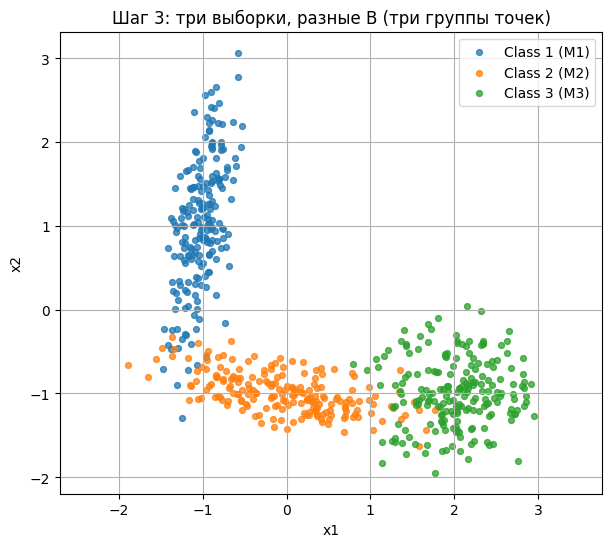

In [9]:
params = {
    "B1": {"sigma1": 0.20, "sigma2": 0.80, "rho":  0.50},
    "B2": {"sigma1": 0.70, "sigma2": 0.25, "rho": -0.60},
    "B3": {"sigma1": 0.45, "sigma2": 0.45, "rho":  0.05},
}

B1 = covariance_from_sigmas_rho(**params["B1"])
B2 = covariance_from_sigmas_rho(**params["B2"])
B3 = covariance_from_sigmas_rho(**params["B3"])

X1 = sample_gaussian_2d(M1, B1, N, rng)
X2 = sample_gaussian_2d(M2, B2, N, rng)
X3 = sample_gaussian_2d(M3, B3, N, rng)

M1_hat, B1_hat = mle_estimates(X1)
M2_hat, B2_hat = mle_estimates(X2)
M3_hat, B3_hat = mle_estimates(X3)


print("B1=\n", B1, "\nmax|B1-AA^T|=", check_B_equals_AAT(B1))
print("Class 1: M_hat =", M1_hat, "\nB_hat=\n", B1_hat)

print("B2=\n", B2, "\nmax|B2-AA^T|=", check_B_equals_AAT(B2))
print("Class 2: M_hat =", M2_hat, "\nB_hat=\n", B2_hat)

print("B3=\n", B3, "\nmax|B3-AA^T|=", check_B_equals_AAT(B3))
print("Class 3: M_hat =", M3_hat, "\nB_hat=\n", B3_hat)

rhoB_12 = bhattacharyya_distance(M1, B1, M2, B2)
rhoB_13 = bhattacharyya_distance(M1, B1, M3, B3)
rhoB_23 = bhattacharyya_distance(M2, B2, M3, B3)

print("\nРасстояния Бхатачария:")
print("rho_B(1,2) =", rhoB_12)
print("rho_B(1,3) =", rhoB_13)
print("rho_B(2,3) =", rhoB_23)

plot_2d_samples([X1, X2, X3], ["Class 1 (M1)", "Class 2 (M2)", "Class 3 (M3)"],
                "Шаг 3: три выборки, разные B (три группы точек)")

np.save("gauss_step3_class1.npy", X1)
np.save("gauss_step3_class2.npy", X2)
np.save("gauss_step3_class3.npy", X3)
